# Unemployment Analysis 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')

In [2]:
df = pd.read_csv("Unemployment in India.csv")

df.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural


In [ ]:
#dataset overview 
print("Shape:", df.shape)

print("\nColumns:")
print(df.columns)

print("\nMissing Values:")
print(df.isnull().sum())

Shape: (768, 7)

Columns:
Index(['Region', ' Date', ' Frequency', ' Estimated Unemployment Rate (%)',
       ' Estimated Employed', ' Estimated Labour Participation Rate (%)',
       'Area'],
      dtype='object')

Missing Values:
Region                                      28
 Date                                       28
 Frequency                                  28
 Estimated Unemployment Rate (%)            28
 Estimated Employed                         28
 Estimated Labour Participation Rate (%)    28
Area                                        28
dtype: int64


In [4]:
df.columns = df.columns.str.strip()

print(df.columns)

Index(['Region', 'Date', 'Frequency', 'Estimated Unemployment Rate (%)',
       'Estimated Employed', 'Estimated Labour Participation Rate (%)',
       'Area'],
      dtype='object')


In [5]:
df.dropna(inplace=True)

print("New Shape:", df.shape)

New Shape: (740, 7)


In [6]:
df['Date'] = pd.to_datetime(
    df['Date'],
    dayfirst=True
)

df.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,2019-05-31,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,2019-06-30,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,2019-07-31,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,2019-08-31,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,2019-09-30,Monthly,5.17,12256762.0,44.68,Rural


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 740 entries, 0 to 753
Data columns (total 7 columns):
 #   Column                                   Non-Null Count  Dtype         
---  ------                                   --------------  -----         
 0   Region                                   740 non-null    object        
 1   Date                                     740 non-null    datetime64[ns]
 2   Frequency                                740 non-null    object        
 3   Estimated Unemployment Rate (%)          740 non-null    float64       
 4   Estimated Employed                       740 non-null    float64       
 5   Estimated Labour Participation Rate (%)  740 non-null    float64       
 6   Area                                     740 non-null    object        
dtypes: datetime64[ns](1), float64(3), object(3)
memory usage: 46.2+ KB


In [8]:
df.describe()

,Date,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%)
count,740,740.000000,7.400000e+02,740.000000
mean,2019-12-12 18:36:58.378378496,11.787946,7.204460e+06,42.630122
min,2019-05-31 00:00:00,0.000000,4.942000e+04,13.330000
25%,2019-08-31 00:00:00,4.657500,1.190404e+06,38.062500
50%,2019-11-30 00:00:00,8.350000,4.744178e+06,41.160000
75%,2020-03-31 00:00:00,15.887500,1.127549e+07,45.505000
max,2020-06-30 00:00:00,76.740000,4.577751e+07,72.570000
std,NaN,10.721298,8.087988e+06,8.111094


# unemployment distribution 

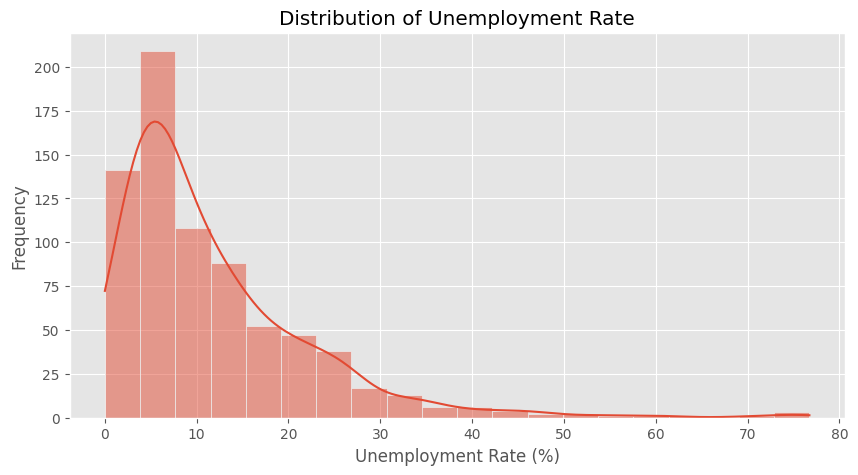

In [9]:
plt.figure(figsize=(10,5))

sns.histplot(
    df['Estimated Unemployment Rate (%)'],
    bins=20,
    kde=True
)

plt.title("Distribution of Unemployment Rate")
plt.xlabel("Unemployment Rate (%)")
plt.ylabel("Frequency")

plt.show()

# TOP 10 stats with highest Unemployment 

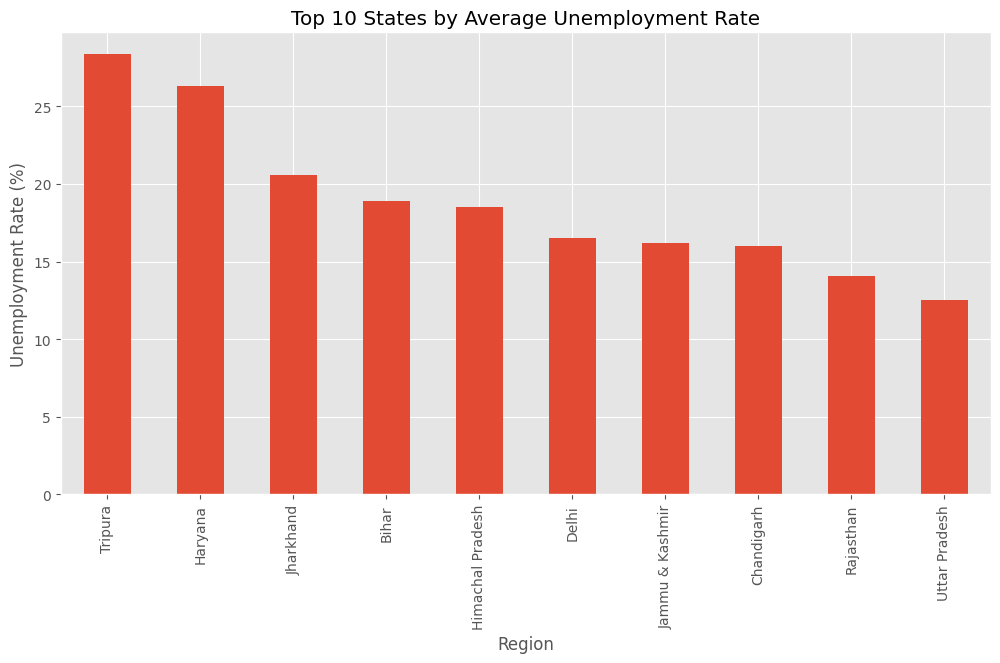

In [10]:
state_unemployment = df.groupby('Region')[
    'Estimated Unemployment Rate (%)'
].mean().sort_values(ascending=False)

plt.figure(figsize=(12,6))

state_unemployment.head(10).plot(
    kind='bar'
)

plt.title("Top 10 States by Average Unemployment Rate")
plt.ylabel("Unemployment Rate (%)")

plt.show()

# urban vs Rural Analysis 

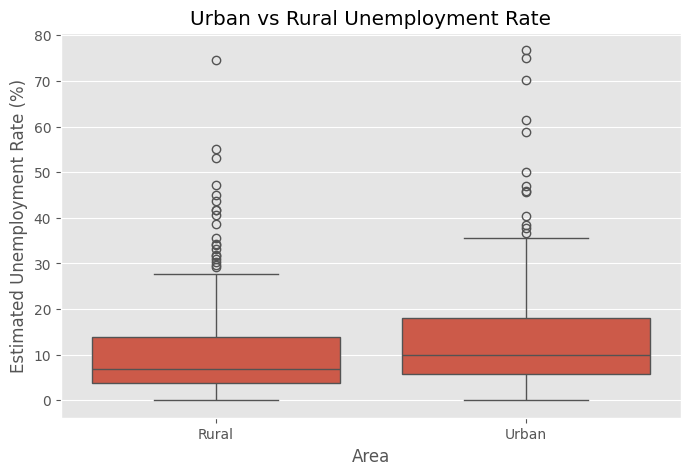

In [11]:

plt.figure(figsize=(8,5))

sns.boxplot(
    x='Area',
    y='Estimated Unemployment Rate (%)',
    data=df
)

plt.title("Urban vs Rural Unemployment Rate")

plt.show()

# monthly trends Analysis 

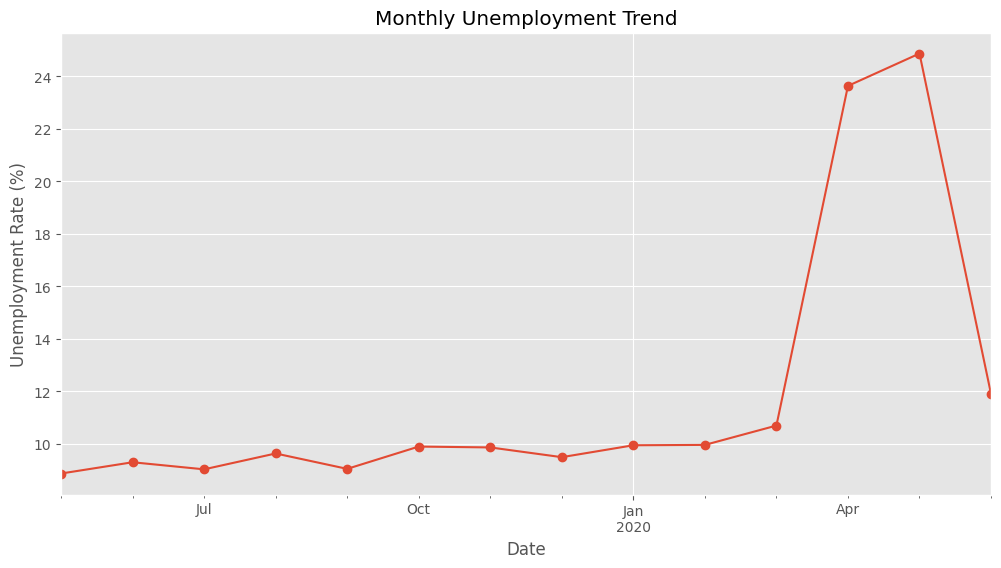

In [12]:
monthly_trend = df.groupby(
    df['Date'].dt.to_period('M')
)['Estimated Unemployment Rate (%)'].mean()

monthly_trend.plot(
    figsize=(12,6),
    marker='o'
)

plt.title("Monthly Unemployment Trend")
plt.ylabel("Unemployment Rate (%)")

plt.show()

# covid 19 impact Analysis 

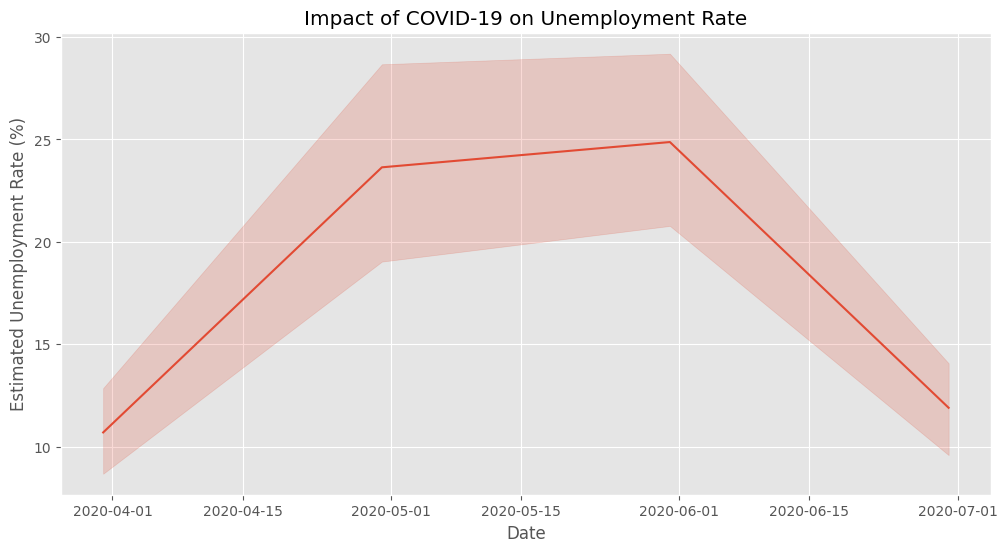

In [13]:
covid_data = df[
    df['Date'] >= '2020-03-01'
]

plt.figure(figsize=(12,6))

sns.lineplot(
    x='Date',
    y='Estimated Unemployment Rate (%)',
    data=covid_data
)

plt.title("Impact of COVID-19 on Unemployment Rate")

plt.show()

# correlation heatmap 

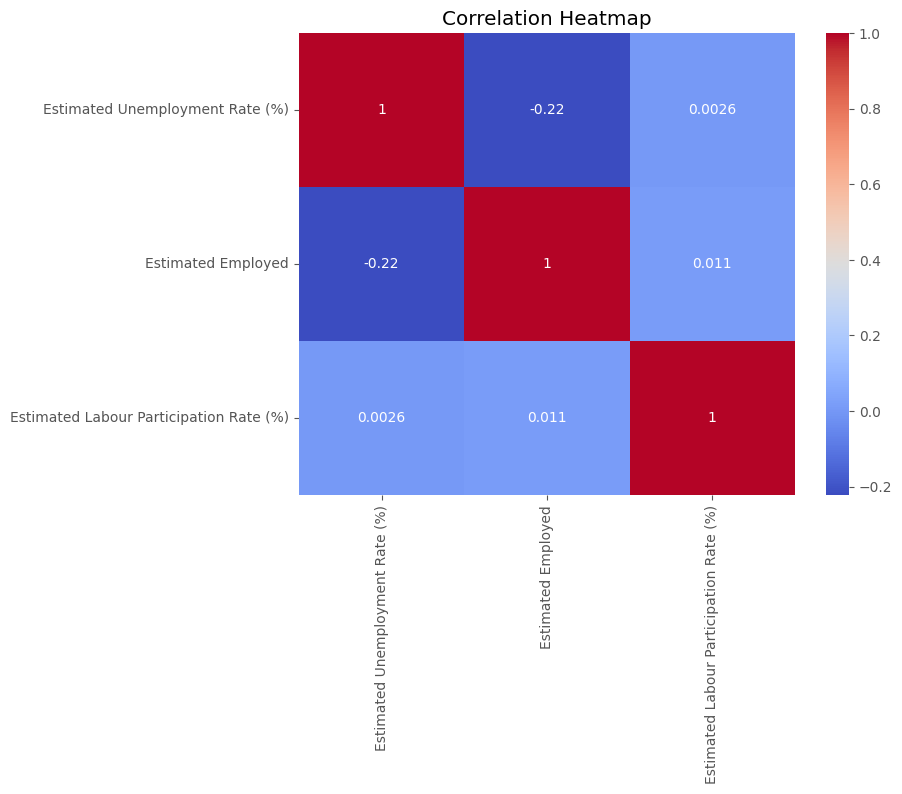

In [14]:
numeric_df = df.select_dtypes(
    include=['number']
)

plt.figure(figsize=(8,6))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.show()

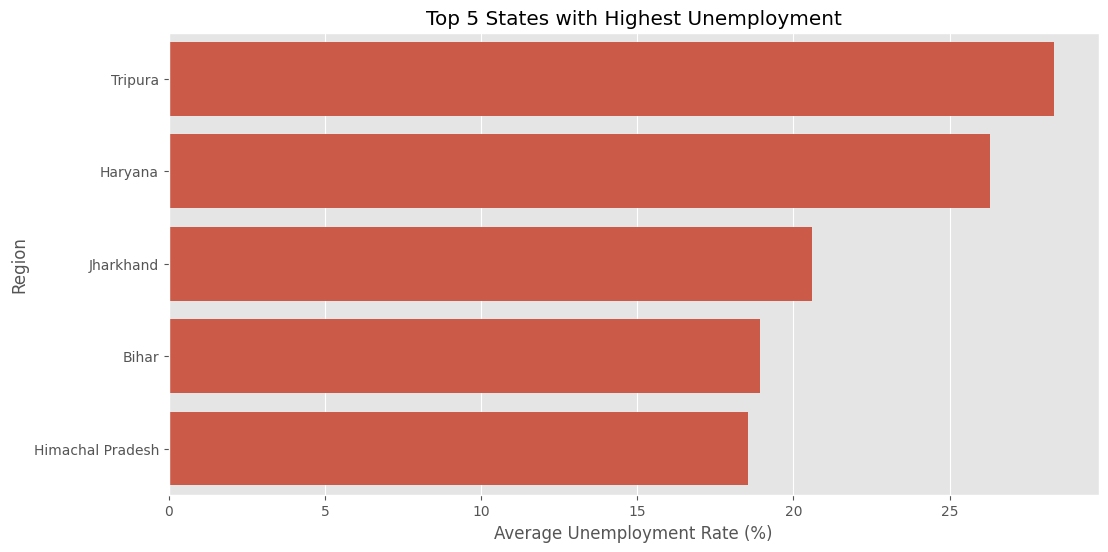

In [16]:
plt.figure(figsize=(12,6))

top_states = df.groupby('Region')[
    'Estimated Unemployment Rate (%)'
].mean().sort_values(ascending=False).head(5)

sns.barplot(
    x=top_states.values,
    y=top_states.index
)

plt.title("Top 5 States with Highest Unemployment")
plt.xlabel("Average Unemployment Rate (%)")

plt.show()

In [15]:
print("Average Unemployment Rate:",
      round(df['Estimated Unemployment Rate (%)'].mean(),2))

print("Highest Unemployment Rate:",
      round(df['Estimated Unemployment Rate (%)'].max(),2))

print("Lowest Unemployment Rate:",
      round(df['Estimated Unemployment Rate (%)'].min(),2))

Average Unemployment Rate: 11.79
Highest Unemployment Rate: 76.74
Lowest Unemployment Rate: 0.0
